light gbm 부터는 category 로 만들고 더미변수 만들 필요도 없음


훈련 데이터의 rmse 가 더 낮게 나와야함


booster_


얘는 바로 시리즈로 줌...
후처리 방식같은거 다 다름




# [LAB 08] 지도학습 > 예측 > 앙상블 > 06.Light GBM

## #01.LightGBM 개요
- 결정 트리 기반 그래디언트 부스팅 회귀 모델
- 잔차를 학습하는 트리들을 순차적으로 결합하여 예측 성능을 향상시키는 부스팅 계열 모델
- Microsoft 에서 개발한 고성능 부스팅 라이브러리
- XGBoost 대비 학습 속도와 메모리 효율을 크게 개선한 모델


### [1] 핵심 구조적 특징
#### (1) Leaf-wise 트리 성장 방식
- 라이트 GBM 은 즉, 손실을 가장 많이 줄일 수 있는 리프만 계속 분할해가서 한쪽으로만 트리가 길어질 수 있음
- 기존 트리 모델 (XGBoost,RandomForest) 은 Level-wise 방식
- 같은 깊이에 있는 모든 노드들을 한꺼번에 분할
- Light GBM 은 Leaf-wise 방식 사용
- 손실 감소가 가장 큰 리프부터 분할
- 같은트리 개수더라도 더 복잡한 패턴을 빠르게 학습 가능
- 단점 : 데이터가 적으면 과적합 위험 증가,max_depth와 num_leaves 제어 필수


#### (2) 히스토그램 기반 분할 (Histogram-based)
- 연속형 변수를 bin으로 압축하여 분기 계산
- 계산량과 메모리 사용량 대폭 감소
-> 대규모 데이터에 특히 유리

### [2] 범주형 변수 처리 특징 (중요)
- LightGBM 은 명목형 변수의 native 처리 지원
- 원 핫 인코딩 불필요
- 범주 분할 시 통계기반 최적 분할 수행
- dtype 은 category 로 명시해야함
- 대규모 범주현 변수에서 XGBoost 보다 안정적이고 효율적

## #02 준비작업
### [1] 패키지 참조

In [49]:
from hossam import *

import pandas as pd
from pandas import Series, DataFrame

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from itertools import product

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# 성능평가지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor


#LightGBM 회귀 모델
from lightgbm import LGBMRegressor

import pandas as pd


#BoostRegressor
from xgboost import XGBRegressor

### [2] 성능 평가 함수 정의
- hs_get_scores()
- hs_learning_cv()
- hs_get_score_cv()
- hs_feature_importance()
- hs_shap_analysis()
- hs_shap_dependence_analysis()-

#### 성능 평가 함수

In [50]:
def hs_get_scores(estimator, x_test, y_true):
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    y_pred = estimator.predict(x_test)

    return DataFrame(
        {
            "결정계수(R2)": r2_score(y_true, y_pred),
            "평균절대오차(MAE)": mean_absolute_error(y_true, y_pred),
            "평균제곱오차(MSE)": mean_squared_error(y_true, y_pred),
            "평균오차(RMSE)": np.sqrt(mean_squared_error(y_true, y_pred)),
            "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
                y_true, y_pred
            ),
            "평균 비율 오차(MPE)": np.mean((y_true - y_pred) / y_true * 100),
        },
        index=[classname],
    )

#### 변수 중요도 확인

In [51]:
from sklearn.inspection import permutation_importance

def hs_feature_importance(model, x, y):
    perm = permutation_importance(
        estimator=model,
        X=x,
        y=y,
        scoring="r2",
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
    )

    # 결과 정리
    perm_df = DataFrame(
        {
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        },
        index=x.columns,
    ).sort_values("importance_mean", ascending=False)

    # 시각화
    df = perm_df.sort_values(by="importance_mean", ascending=False)

    figsize = (1280 / my_dpi, 600 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.barplot(data=df, x="importance_mean", y=df.index)

    ax.set_title("Permutation Importance")
    ax.set_xlabel("Permutation Importance (mean)")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    return perm_df


#### 과적합 판정 함수

In [52]:
import matplotlib.pyplot as plt

my_dpi = 100  # 없으면 기본값

def create_figure(figsize=(1280/100, 720/100), dpi=None):
    if dpi is None:
        dpi = my_dpi
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    return fig, ax

def finalize_plot(ax):
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()


In [53]:
def hs_learning_cv(
    estimator, x, y, scoring="neg_root_mean_squared_error",
    cv=5, train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
):

    train_sizes, train_scores, cv_scores = learning_curve(  # type: ignore
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 정량 판정
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과소적합 기준선 (some_threshold)
    # -------------------------

    # 기준모형 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    # → 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도의 성능은 내야 한다는 기준을 설정하는 것
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "⚠️ 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "⚠️ 과대적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "⚠️ 데이터 부족 / 분산 큼"
    else:
        status = "⚠️ 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "Train RMSE": [final_train],
            "CV RMSE 평균": [final_cv],
            "CV RMSE 표준편차": [final_std],
            "Train/CV 비율": [gap_ratio],
            "CV 변동성 비율": [var_ratio],
            "판정 결과": [status],
        },
        index=[classname],
    )

    # display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------

    fig, ax = create_figure()

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    ax.set_xlabel("RMSE", fontsize=8, labelpad=5)  # type: ignore
    ax.set_ylabel("학습곡선 (Learning Curve)", fontsize=8, labelpad=5)  # type: ignore
    ax.grid(True, alpha=0.3)  # type: ignore

    finalize_plot(ax)

    return result_df


#### 성능평가 + 과적합 판정 동시 수행 함수

In [54]:
def hs_get_score_cv(
    estimator,
    x_test,
    y_test,
    x_origin,
    y_origin,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):

    score_df = hs_get_scores(estimator, x_test, y_test)

    cv_df = hs_learning_cv(
        estimator,
        x_origin,
        y_origin,
        scoring=scoring,
        cv=cv,
        train_sizes=train_sizes,
        n_jobs=n_jobs,
    )

    return merge(score_df, cv_df, left_index=True, right_index=True)


#### SHAP 분석

In [55]:
def hs_shap_analysis(
    model,
    x: DataFrame,
    plot: bool = True,
    width: int = 1600,
    height: int = 800,
):
    # -------------------------------------------------
    # 1. SHAP Explainer 생성 (트리 모델용)
    # -------------------------------------------------
    explainer = shap.TreeExplainer(model)

    # -------------------------------------------------
    # 2. SHAP 값 계산
    # shape = (n_samples, n_features)
    # -------------------------------------------------
    shap_values = explainer.shap_values(x)

    # -------------------------------------------------
    # 3. SHAP DataFrame 변환
    # -------------------------------------------------
    shap_df = DataFrame(
        shap_values,
        columns=x.columns,
        index=x.index,
    )

    # -------------------------------------------------
    # 4. SHAP 요약 통계
    # -------------------------------------------------
    summary_df = DataFrame(
        {
            "feature": shap_df.columns,
            "mean_abs_shap": shap_df.abs().mean().values,
            "mean_shap": shap_df.mean().values,
            "std_shap": shap_df.std().values,
        }
    )

    # -------------------------------------------------
    # 5. 영향 방향 (보수적 기준)
    # -------------------------------------------------
    summary_df["direction"] = np.where(
        summary_df["mean_shap"] > 0,
        "양(+) 경향",
        np.where(summary_df["mean_shap"] < 0, "음(-) 경향", "혼합/미약"),
    )

    # -------------------------------------------------
    # 6. 변동성 지표 (안정성 판단)
    # -------------------------------------------------
    summary_df["cv"] = (
        summary_df["std_shap"] / (summary_df["mean_abs_shap"] + 1e-9)
    )

    summary_df["variability"] = np.where(
        summary_df["cv"] < 1,
        "stable",      # 평균 대비 변동성 낮음
        "variable",    # 상황 의존적 영향
    )

    # -------------------------------------------------
    # 7. 중요도 기준 정렬
    # -------------------------------------------------
    summary_df = (
        summary_df
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    # -------------------------------------------------
    # 8. 중요 변수 판별 (누적 80%)
    # -------------------------------------------------
    total_importance = summary_df["mean_abs_shap"].sum()

    summary_df["importance_ratio"] = (
        summary_df["mean_abs_shap"] / total_importance
    )

    summary_df["importance_cumsum"] = (
        summary_df["importance_ratio"].cumsum()
    )

    summary_df["is_important"] = np.where(
        summary_df["importance_cumsum"] <= 0.80,
        "core",        # 핵심 변수
        "secondary",   # 보조 변수
    )

    # -------------------------------------------------
    # 9. SHAP Summary Plot
    # -------------------------------------------------
    if plot:
        shap.summary_plot(shap_values, x, show=False)

        fig = plt.gcf()
        fig.set_size_inches(width / 100, height / 100)

        plt.title("SHAP Summary Plot", fontsize=10, pad=10)
        plt.xlabel("SHAP value", fontsize=8)
        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    # -------------------------------------------------
    return summary_df, shap_values


#### SHAP dependance

In [56]:
def hs_shap_dependence_analysis(
    summary_df: DataFrame,
    shap_values,
    x_train: DataFrame,
    include_secondary: bool = False, #core 변수가 너무 적을 때, True 로 설정하면 secondary 까지 포함
    width: int = 1600,
    height: int = 800,
):
    # 1. 주 대상 변수 (Core + Variable)
    main_features = summary_df[
        (summary_df["is_important"] == "core")
        & (summary_df["variability"] == "variable")
    ]["feature"].tolist()

    # 2. 상호작용 후보 변수
    interaction_features = summary_df[
        summary_df["is_important"] == "core"
    ]["feature"].tolist()

    if include_secondary and len(interaction_features) < 2:
        interaction_features.extend(
            summary_df[summary_df["is_important"] == "secondary"]["feature"].tolist()
        )

    # 3. 변수 쌍 생성 (자기 자신 제외)
    pairs = []
    for f in main_features:
        for inter in interaction_features:
            # 자기 자신과의 조합은 제외
            if f != inter:
                pairs.append((f, inter))

    # 중요도 순 정렬 (주 변수 기준)
    importance_rank = {}
    for i, row in summary_df.iterrows():
        importance_rank[row["feature"]] = i

    pairs = sorted(
        pairs,
        key=lambda x: importance_rank.get(x[0], 999),
    )

    # 4. dependence plot 일괄 생성
    for feature_name, interaction_name in pairs:
        shap.dependence_plot(
            feature_name,
            shap_values,
            x_train,
            interaction_index=interaction_name,
            show=False,
        )

        # SHAP figure 직접 제어
        fig = plt.gcf()
        fig.set_size_inches(width / my_dpi, height / my_dpi)

        plt.title(
            f"SHAP Dependence Plot: {feature_name} × {interaction_name}",
            fontsize=10,
            pad=10,
        )

        plt.xlabel(feature_name, fontsize=10)
        plt.ylabel(f"SHAP value for {feature_name}", fontsize=10)

        plt.xticks(fontsize=6)
        plt.yticks(fontsize=8)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        plt.close()

    return pairs


### [3] 데이터 가져오기 + 인덱스 ,명목형 변환

In [57]:
origin = load_data("restaurant_sales_preprocessed")
origin.set_index("date", inplace=True)


# XGBoost 라서 astype int 처리
origin["holiday"] = origin["holiday"].astype("category")
origin["weekend"] = origin["weekend"].astype("category")
origin.info()


어느 식당의 1년간 일별 매출을 기록한 데이터의 전처리 완료 버전(명목형이 이진변수만 있으므로 더미변수는 처리하지 않음)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sales           353 non-null    float64 
 1   visitors        353 non-null    int64   
 2   avg_price       353 non-null    int64   
 3   marketing_cost  353 non-null    float64 
 4   delivery_ratio  353 non-null    float64 
 5   rain_mm         353 non-null    float64 
 6   temperature     353 non-null    float64 
 7   holiday         353 non-null    category
 8   weekend         353 non-null    category
dtypes: category(2), float64(5), int64(2)
memory usage: 23.0 KB


### [4] 훈련, 학습 데이터 분리

In [58]:
df = origin

yname = "sales"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((264, 8), (89, 8), (264,), (89,))

## #03. LightGBM 모델 적합
### [1] 주요 하이퍼 파라미터


| 파라미터 | 핵심도 | 역할 | 기본값 | 주 용도 / 튜닝 포인트 |
|--------|------|----------------------|--------|------------------|
| n_estimators | ⭐⭐⭐ | 부스팅 트리 개수 | 100 | 많을수록 학습량 ↑, 과적합 위험 ↑ |
| learning_rate | ⭐⭐⭐ | 각 트리의 기여도 | 0.1 | 작을수록 안정적, 대신 트리 수 필요 |
| num_leaves | ⭐⭐⭐ | 리프 개수 (복잡도 핵심) | 31 | 클수록 복잡, 과적합 위험 ↑ |
| max_depth | ⭐⭐⭐ | 트리 최대 깊이 | -1 | leaf-wise 과적합 제어 |
| min_child_samples | ⭐⭐⭐ | 리프 최소 샘플 수 | 20 | 작으면 과적합, 크면 보수적 |
| min_child_weight | ⭐⭐ | 리프 최소 가중치 합 | 1e-3 | 이상치·노이즈 제어 |
| subsample | ⭐⭐ | 행(row) 샘플 비율 | 1.0 | 과적합 방지 |
| subsample_freq | ⭐ | 샘플링 적용 빈도 | 0 | 0이면 미적용 |
| reg_alpha | ⭐⭐ | L1 정규화 계수 | 0.0 | 변수 선택 효과 |
| reg_lambda | ⭐⭐ | L2 정규화 계수 | 0.0 | 계수 안정화 |
| objective | ⭐ | 손실 함수 | regression | 문제 유형 결정 |
| random_state | ✅ | 재현성 시드 | None | 결과 고정 |
| n_jobs | ✅ | 병렬 처리 | -1 | 학습 속도 |



[각 파라미터별 핵심 설명]
1. n_estimators - 트리를 몇 개 쌓을까 (부스팅 단계수)
2. learning_rate - 한번에 얼마나 고칠까 (새 트리가 이전 예측을 얼마나 강하게 수정할지)
3. num_leaves - 한 트리에서 만들 수 있는 리프 개수
4. max_depth - leaf-wise 브레이크 역할로 트리 깊이 제한
5. min_child_samples - 리프 최소 인원, 리프 하나에 들어갈 최소 샘플수
6. min_child_weight - 가중치 버전 안전장치 (min_child_samples 의 연속형 버전)
7. subsample / subsample_freq -일부 row 만 사용해서 트리 학습, 부스팅 + 샘플링 분산 감소 역할
8. reg_alpha / reg_lambda - L1/L2 정규화, L1 은 변수 제거 효과, L2 는 계수 안정화 효과
9. objective - 회귀,이진분류,다중분류 등으로 나눠짐

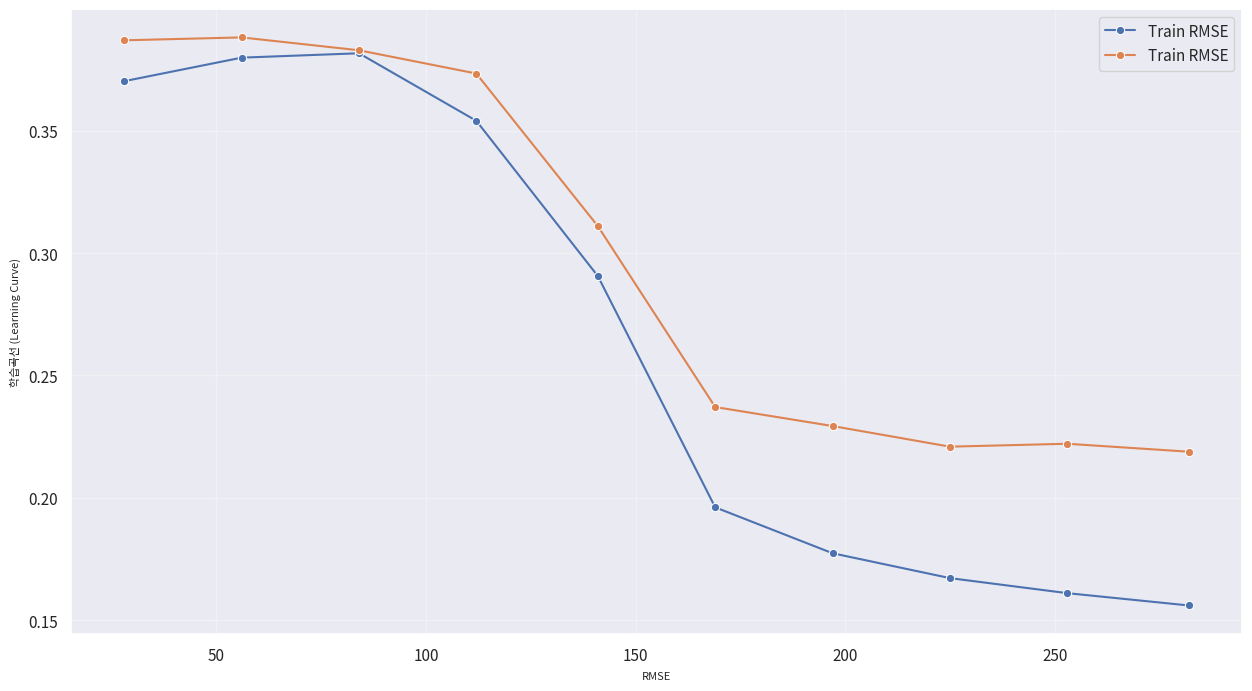

CPU times: total: 1.94 s
Wall time: 20.3 s


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차 비율(MAPE),평균 비율 오차(MPE),Train RMSE,CV RMSE 평균,CV RMSE 표준편차,Train/CV 비율,CV 변동성 비율,판정 결과
LGBMRegressor,0.830,0.126,0.025,0.158,0.008,-0.012,0.156,0.219,0.014,0.713,0.063,⚠️ 과대적합 (variance 큼)


In [59]:
%%time

lgbm = LGBMRegressor(
    objective="regression",
    random_state=52,
    n_jobs=-1,
    verbose=-1
)

param_grid = {
    "n_estimators": [200],          # [100, 300, 500],
    "learning_rate": [0.05, 0.1],   # [0.01, 0.05, 0.1],
    "num_leaves": [31, 63],         # [15, 31, 63],
    "max_depth": [-1, 5],           # [-1, 3, 5, 7],
    "min_child_samples": [20, 50],  # [10, 20, 50],
    "subsample": [0.8],             # [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [0, 1, 5],
}

gs = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gs.fit(x_train, y_train)

best_model = gs.best_estimator_

hs_get_score_cv(best_model, x_train, y_train, x, y)


## #04. 변수 중요도
### [1] 변수 중요도 산출
#### 중요도 확인



In [60]:
booster = best_model.booster_
imp=booster.feature_importance(importance_type='gain')
imp

array([ 4.90301688,  9.66968413, 20.68857066,  2.81705694,  7.827496  ,
        3.31020704, 38.76932895, 77.46855103])

In [61]:
imp_df = DataFrame({"importance": imp}, index=best_model.feature_name_)

# 비율 + 누적합
imp_df["ratio"] = imp_df["importance"] / imp_df["importance"].sum()

imp_df = imp_df.sort_values("importance", ascending=False)
imp_df["cumsum"] = imp_df["ratio"].cumsum()

imp_df


,importance,ratio,cumsum
weekend,77.469,0.468,0.468
holiday,38.769,0.234,0.703
marketing_cost,20.689,0.125,0.828
avg_price,9.670,0.058,0.886
rain_mm,7.827,0.047,0.933
visitors,4.903,0.030,0.963
temperature,3.310,0.020,0.983
delivery_ratio,2.817,0.017,1.000


### [2] 결과 시각화

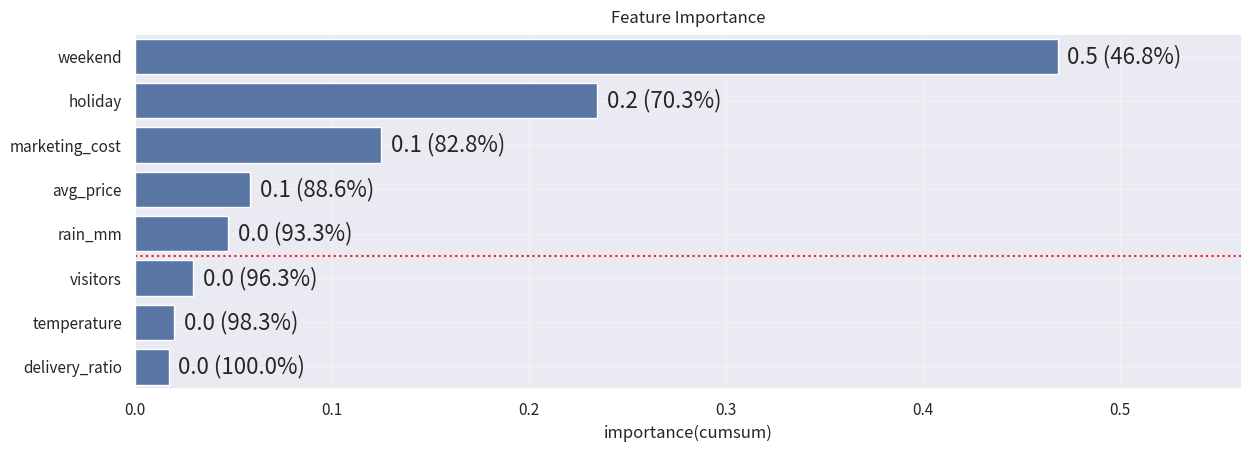

In [62]:
height = len(imp_df) * 60
figsize = (1280 / 100, height / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

sb.barplot(data=imp_df, x='ratio', y=imp_df.index, orient='h')


# 값 라벨 추가
for i, v in enumerate(imp_df["ratio"]):
    ax.text(
        v + 0.005,                                   # 막대 끝에서 약간 오른쪽
        i,                                           # y 위치
        f"{v:.1f} ({imp_df.iloc[i]['cumsum']*100:.1f}%)",  # 표시 형식
        va="center"
    )

ax.set_title("Feature Importance", fontsize=12, pad=8)
ax.set_xlabel("importance(cumsum)", fontsize=12)
ax.set_ylabel(None)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, imp_df["ratio"].max() * 1.2)

threshold = 0.9

# 90% 처음 도달하는 인덱스 (0-based)
cut_idx = np.argmax(imp_df["cumsum"].values >= threshold)

# 축상 rank 기준으로 +1
cut_rank = (int(cut_idx) + 1) - 0.5

# 90% 도달 지점 수직선 (핵심)
plt.axhline(
    y=cut_rank,
    linestyle=":",
    color="red",
    alpha=0.9
)

plt.tight_layout()
plt.show()
plt.close()


### [3] 변수 중요도 확인 함수 개선
XGBoost 와 그 외의 경우를 통합하여 처리하도록 분기 처리 추가


In [65]:
from sklearn.inspection import permutation_importance

def hs_feature_importance(model, x_train, y_train):
    # ---------------------------
    # 1. 중요도 계산
    # ---------------------------
    if isinstance(model, XGBRegressor):
        booster = model.get_booster()
        imp = booster.get_score(importance_type="gain")
        imp_df = DataFrame(
            Series(imp),
            columns=["importance"]
        )

    elif isinstance(model, LGBMRegressor):
        booster = model.booster_
        imp = booster.feature_importance(importance_type="gain")
        imp_df = DataFrame(
            {"importance": imp},
            index=model.feature_name_
        )

    else:
        perm = permutation_importance(
            estimator=model,
            X=x_train,
            y=y_train,
            scoring="r2",
            n_repeats=30,
            random_state=42,
            n_jobs=-1,
        )

        imp_df = DataFrame(
            {"importance": perm.importances_mean},
            index=x_train.columns
        )

    # ---------------------------
    # 2. 비율 + 누적 중요도
    # ---------------------------
    imp_df["ratio"] = imp_df["importance"] / imp_df["importance"].sum()
    imp_df.sort_values("ratio", ascending=False, inplace=True)
    imp_df["cumsum"] = imp_df["ratio"].cumsum()

    return imp_df


In [66]:
hs_feature_importance(best_model,x_train,y_train)

,importance,ratio,cumsum
weekend,77.469,0.468,0.468
holiday,38.769,0.234,0.703
marketing_cost,20.689,0.125,0.828
avg_price,9.670,0.058,0.886
rain_mm,7.827,0.047,0.933
visitors,4.903,0.030,0.963
temperature,3.310,0.020,0.983
delivery_ratio,2.817,0.017,1.000


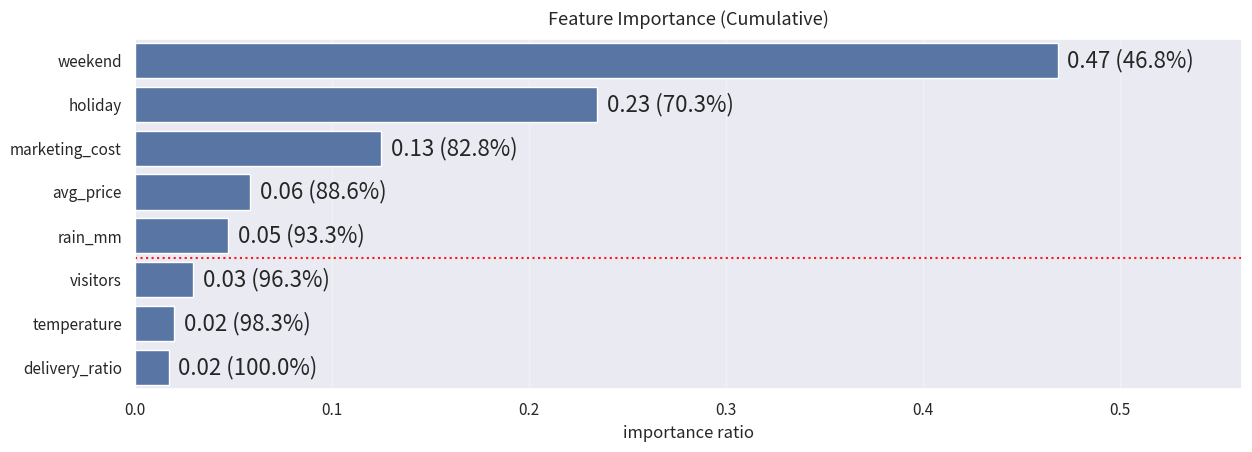

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# ---------- 기본 설정 ----------
threshold = 0.9   # 90% 기준
my_dpi = 100

height = len(imp_df) * 60
figsize = (1280 / my_dpi, height / my_dpi)

fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

# ---------- barplot ----------
sb.barplot(
    data=imp_df,
    x="ratio",
    y=imp_df.index,
    orient="h",
    ax=ax
)

# ---------- 값 + 누적비율 라벨 ----------
for i, v in enumerate(imp_df["ratio"]):
    ax.text(
        v + 0.005,
        i,
        f"{v:.2f} ({imp_df.iloc[i]['cumsum']*100:.1f}%)",
        va="center"
    )

# ---------- 90% 도달 위치 ----------
cut_idx = np.argmax(imp_df["cumsum"].values >= threshold)
cut_rank = (int(cut_idx) + 1) - 0.5

# ---------- 빨간 점선 ----------
ax.axhline(
    y=cut_rank,
    linestyle=":",
    color="red",
    alpha=0.9
)

# ---------- 스타일 ----------
ax.set_title("Feature Importance (Cumulative)", fontsize=13, pad=10)
ax.set_xlabel("importance ratio", fontsize=12)
ax.set_ylabel(None)
ax.grid(True, axis="x", alpha=0.3)
ax.set_xlim(0, imp_df["ratio"].max() * 1.2)

plt.tight_layout()
plt.show()
plt.close()


## #05.SHAP 분석

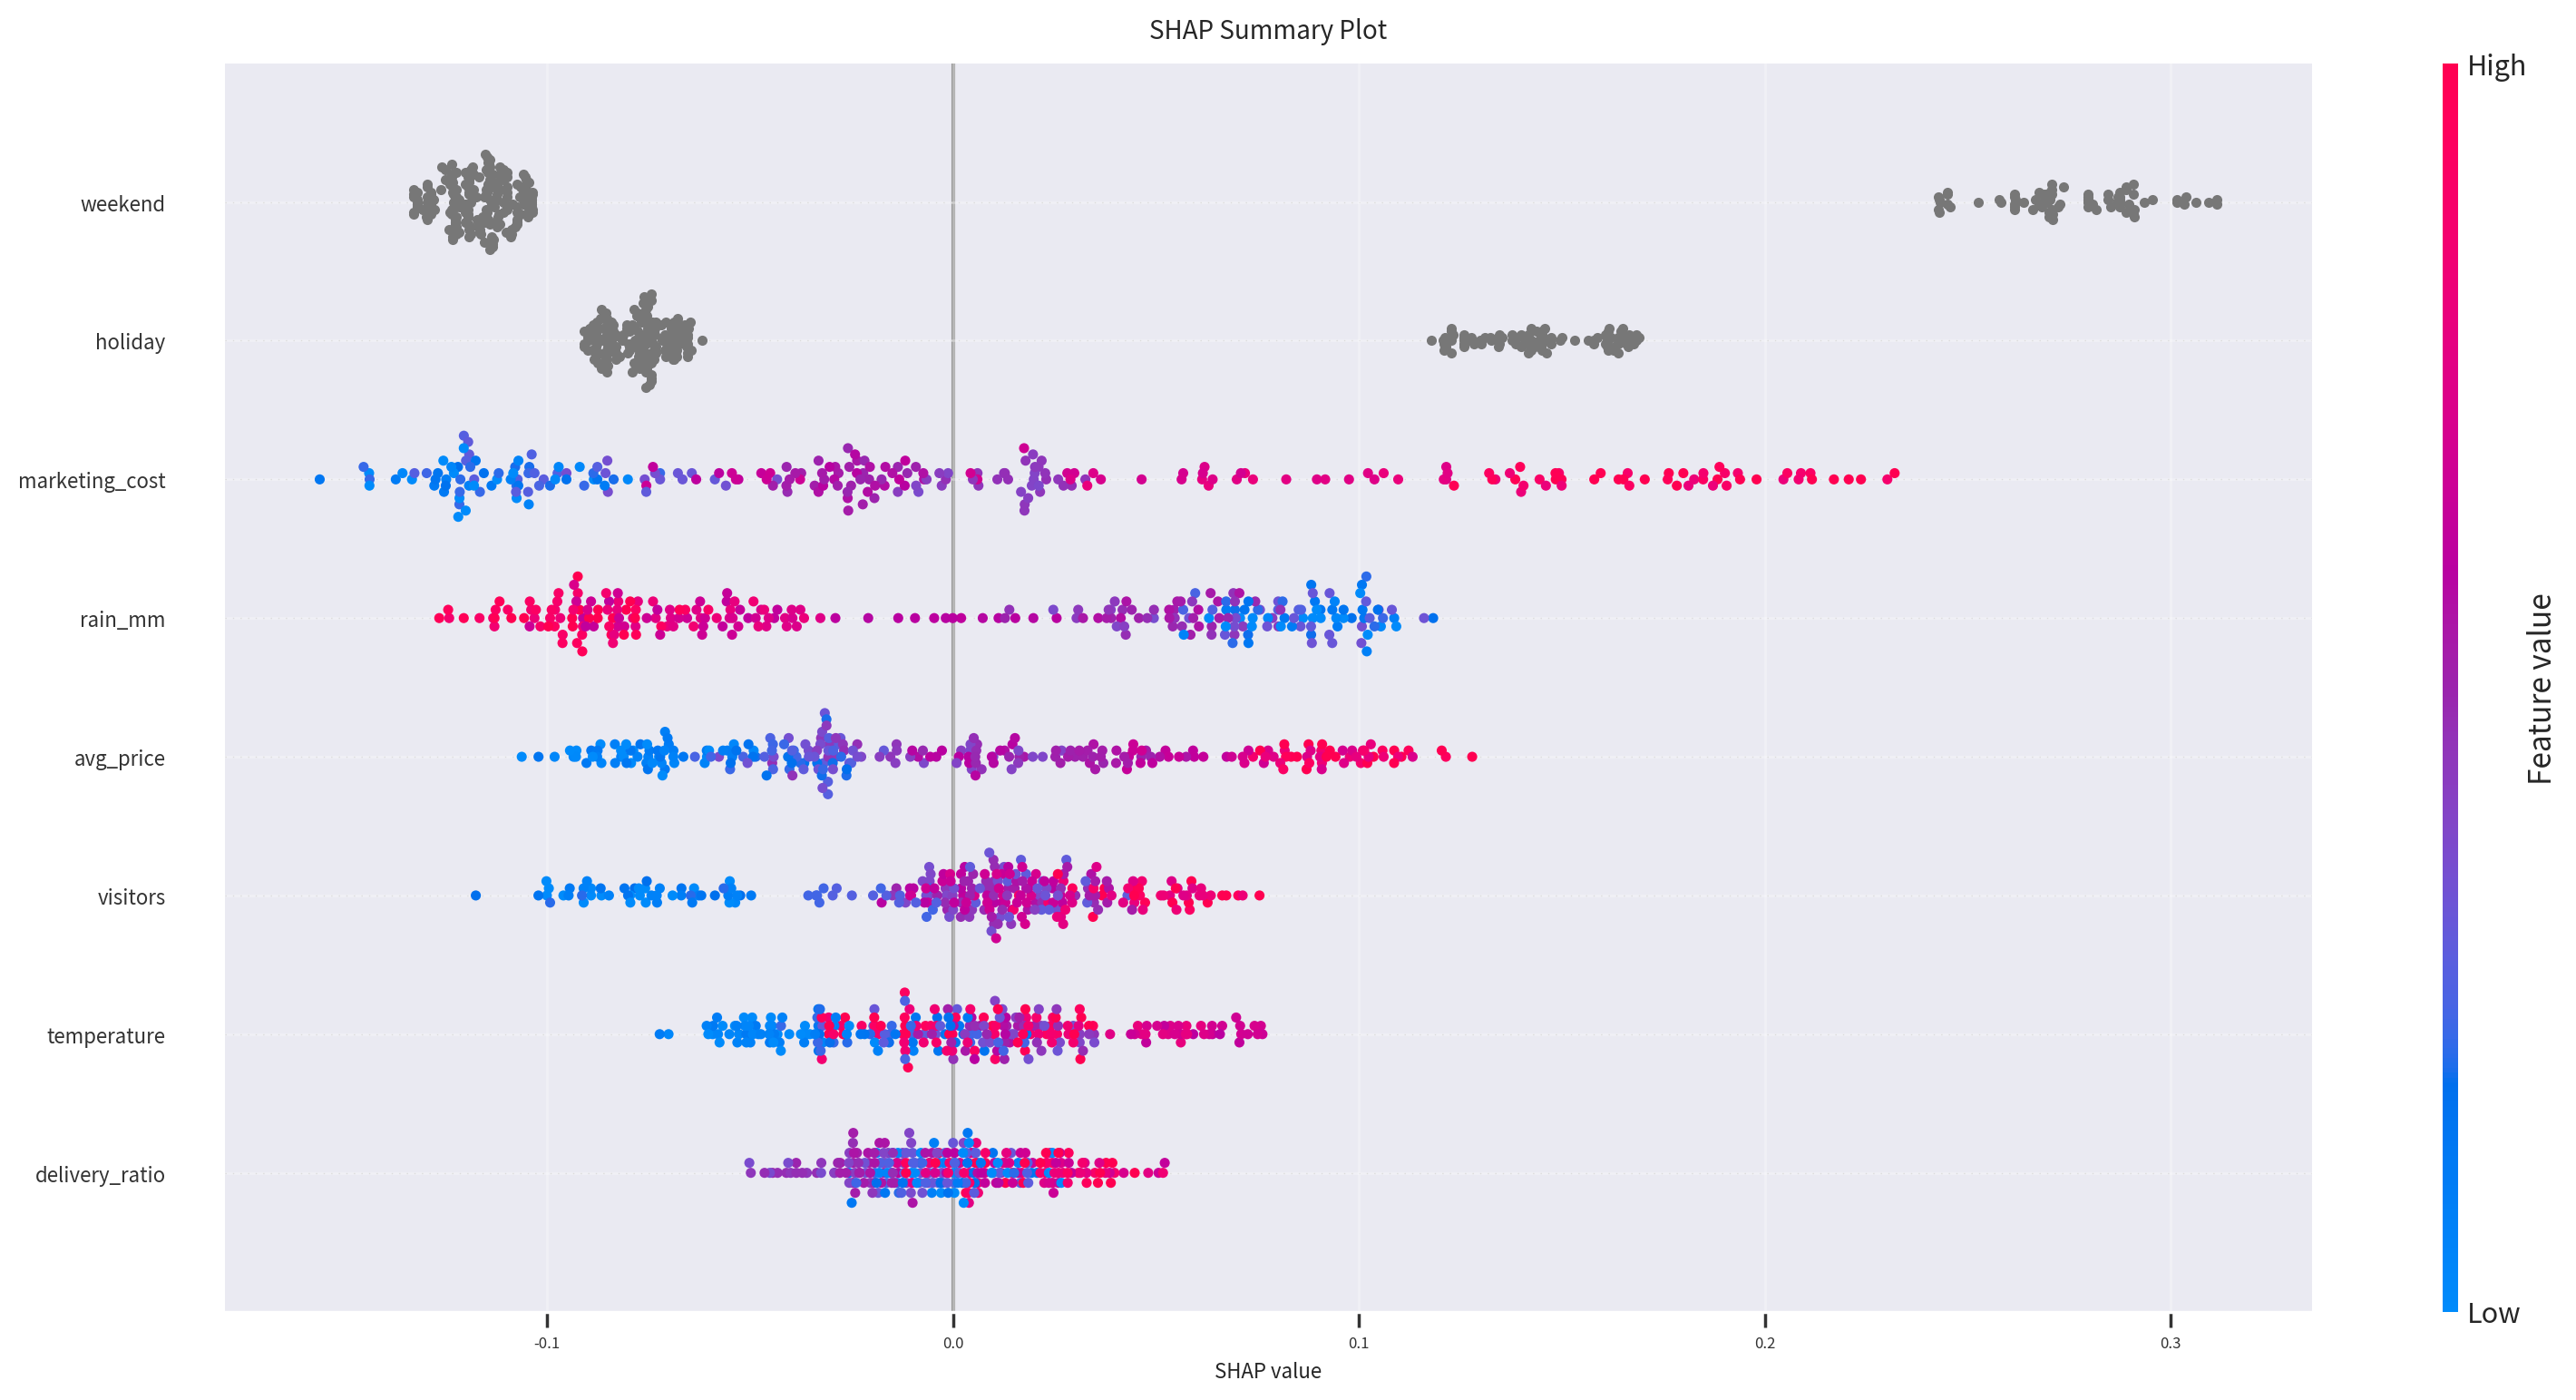

,feature,mean_abs_shap,mean_shap,std_shap,direction,cv,variability,importance_ratio,importance_cumsum,is_important
0,weekend,0.164,0.001,0.180,양(+) 경향,1.098,variable,0.296,0.296,core
1,holiday,0.101,-0.000,0.107,음(-) 경향,1.056,variable,0.182,0.479,core
2,marketing_cost,0.086,0.001,0.105,양(+) 경향,1.220,variable,0.155,0.633,core
3,rain_mm,0.073,-0.001,0.077,음(-) 경향,1.065,variable,0.131,0.764,core
4,avg_price,0.053,-0.000,0.061,음(-) 경향,1.162,variable,0.095,0.859,secondary
5,visitors,0.033,-0.000,0.043,음(-) 경향,1.307,variable,0.059,0.919,secondary
6,temperature,0.028,0.001,0.034,양(+) 경향,1.232,variable,0.050,0.969,secondary
7,delivery_ratio,0.017,-0.000,0.021,음(-) 경향,1.232,variable,0.031,1.000,secondary


In [70]:
import shap

result,_ = hs_shap_analysis(best_model,x_train)
result